<a href="https://colab.research.google.com/github/EmiliaNahapetyan/CNN_homework/blob/main/sms_spam_detection_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📧 Spam Detection in Electronic Messages Using Machine Learning Methods
### Bachelor's Diploma Thesis — Final Version (Defense-Ready)

---

## Abstract

Spam messages represent a persistent and growing threat to digital communication, consuming bandwidth, wasting user time, and serving as vectors for phishing and fraud. Despite the availability of commercial filters, the problem remains unsolved in open-source and resource-constrained contexts, and the academic literature lacks a unified comparison of classical and deep learning approaches under identical experimental conditions.

**Research Gap:** Most published benchmarks either evaluate only classical models (missing sequential learning) or only deep learning models (missing interpretable baselines). Furthermore, few studies combine handcrafted linguistic features with learned representations in a systematic ablation.

**Contribution of this work:**
1. A reproducible, end-to-end NLP pipeline covering preprocessing, feature engineering, and multi-model evaluation.
2. A fair head-to-head comparison of four classical algorithms (Naïve Bayes, Logistic Regression, SVM, MLP) and one deep learning model (Bidirectional LSTM) on identical train/test splits.
3. Incorporation of n-gram features and message-level attributes to enrich the classical feature space.
4. A diagnosed and corrected LSTM implementation with anti-overfitting regularization.
5. A complete evaluation suite: confusion matrices, classification reports, model comparison charts, and probability calibration visualization.

---

### Models Implemented
| # | Model | Family | Feature Input |
|---|---|---|---|
| 1 | Naïve Bayes | Probabilistic (Classical) | TF-IDF unigrams |
| 2 | Logistic Regression | Linear (Classical) | TF-IDF (1,2)-grams + Handcrafted |
| 3 | Support Vector Machine | Kernel-based (Classical) | TF-IDF (1,2)-grams + Handcrafted |
| 4 | MLP Neural Network | Feed-forward (Classical DL) | TF-IDF (1,2)-grams + Handcrafted |
| 5 | **LSTM** | Recurrent (Deep Learning) | Token Sequences |

---

> **Dataset:** UCI SMS Spam Collection (5,574 messages)  
> **Language:** Python 3 | **Framework:** TensorFlow / Keras  
> **Environment:** Google Colab


## 🔧 Step 0: Environment Setup

Install and import all required libraries. We use **lemmatization** (WordNetLemmatizer) instead of stemming for linguistically accurate word normalization.

In [ ]:
!pip install wordcloud --quiet

import re, string, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
for r in ['stopwords','punkt','wordnet','omw-1.4','punkt_tab','averaged_perceptron_tagger_eng']:
    nltk.download(r, quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Dropout,
    Bidirectional, SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(f'TensorFlow version : {tf.__version__}')
print('All libraries loaded successfully.')


TensorFlow version : 2.20.0
All libraries loaded successfully.


## ✅ Step 1: Data Loading & Validation

### About the Dataset

We use the **UCI SMS Spam Collection Dataset**, the canonical benchmark for SMS spam research (Almeida et al., 2011). It contains **5,574 tagged SMS messages** with a realistic class imbalance of roughly 87% ham to 13% spam — matching real-world inbox distributions.

This step also includes **data quality checks** for missing values and duplicate entries, which are essential for ensuring the integrity of any experimental result.


In [ ]:
URL = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df  = pd.read_csv(URL, sep='\t', header=None, names=['label', 'message'])

df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

df['msg_length']    = df['message'].apply(len)
df['word_count']    = df['message'].apply(lambda x: len(x.split()))
df['special_chars'] = df['message'].apply(
    lambda x: sum(1 for c in x if c in string.punctuation)
)
df['uppercase_ratio'] = df['message'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)
df['digit_count'] = df['message'].apply(lambda x: sum(c.isdigit() for c in x))

print('=' * 60)
print('  DATA LOADING & VALIDATION REPORT')
print('=' * 60)
print(f'  Total rows loaded        : {df.shape[0]:,}')
print(f'  Columns                  : {list(df.columns)}')
print()

missing = df.isnull().sum()
print('  Missing Values per Column:')
for col, cnt in missing.items():
    status = '✅ None' if cnt == 0 else f'⚠️  {cnt} missing!'
    print(f'    {col:<20} : {status}')
print()

n_dupes = df.duplicated(subset='message').sum()
print(f'  Duplicate messages found : {n_dupes}')
if n_dupes > 0:
    df = df.drop_duplicates(subset='message').reset_index(drop=True)
    print(f'  Duplicates removed. New size: {df.shape[0]:,}')
else:
    print('  ✅ No duplicates — dataset is clean.')
print()

print(f'  Ոչ սպամ (ham)   : {(df.label=="ham").sum():,}  ({(df.label=="ham").mean()*100:.1f}%)')
print(f'  Սպամ (spam)     : {(df.label=="spam").sum():,}  ({(df.label=="spam").mean()*100:.1f}%)')
print('=' * 60)
df.head(6)


  DATA LOADING & VALIDATION REPORT
  Total rows loaded        : 5,572
  Columns                  : ['label', 'message', 'label_num', 'msg_length', 'word_count', 'special_chars', 'uppercase_ratio', 'digit_count']

  Missing Values per Column:
    label                : ✅ None
    message              : ✅ None
    label_num            : ✅ None
    msg_length           : ✅ None
    word_count           : ✅ None
    special_chars        : ✅ None
    uppercase_ratio      : ✅ None
    digit_count          : ✅ None

  Duplicate messages found : 403
  Duplicates removed. New size: 5,169

  Ոչ սպամ (ham)   : 4,516  (87.4%)
  Սպամ (spam)     : 653  (12.6%)


,label,message,label_num,msg_length,word_count,special_chars,uppercase_ratio,digit_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20,9,0.027027,0
1,ham,Ok lar... Joking wif u oni...,0,29,6,6,0.068966,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28,6,0.064516,25
3,ham,U dun say so early hor... U c already then say...,0,49,11,6,0.040816,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13,2,0.032787,0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1,147,32,8,0.047619,4


## ✅ Step 2: Exploratory Data Analysis (EDA)

A thorough exploratory analysis reveals structural differences between spam and ham messages. We examine:
- Class balance and distribution
- Message length and word count statistics
- Most frequent words per class (Spam vs Ham word analysis)
- Wordclouds for visual inspection


In [ ]:
# ── Per-class statistics ──────────────────────────────────────────────────────
print('Per-class descriptive statistics:')
display(df.groupby('label')[['msg_length','word_count','special_chars','uppercase_ratio']].describe().round(2))


Per-class descriptive statistics:


msg_length                                                  word_count  \
           count    mean    std   min    25%    50%    75%    max      count   
label                                                                          
ham       4516.0   70.91  56.72   2.0   34.0   53.0   91.0  910.0     4516.0   
spam       653.0  137.70  29.82  13.0  132.0  148.0  157.0  223.0      653.0   

              ... special_chars        uppercase_ratio                         \
        mean  ...           75%    max           count  mean   std  min   25%   
label         ...                                                               
ham    14.24  ...           5.0  133.0          4516.0  0.06  0.11  0.0  0.02   
spam   23.74  ...           8.0   26.0           653.0  0.11  0.09  0.0  0.05   

                         
        50%   75%   max  
label                    
ham    0.03  0.05  1.00  
spam   0.10  0.14  0.79  

[2 rows x 32 columns]

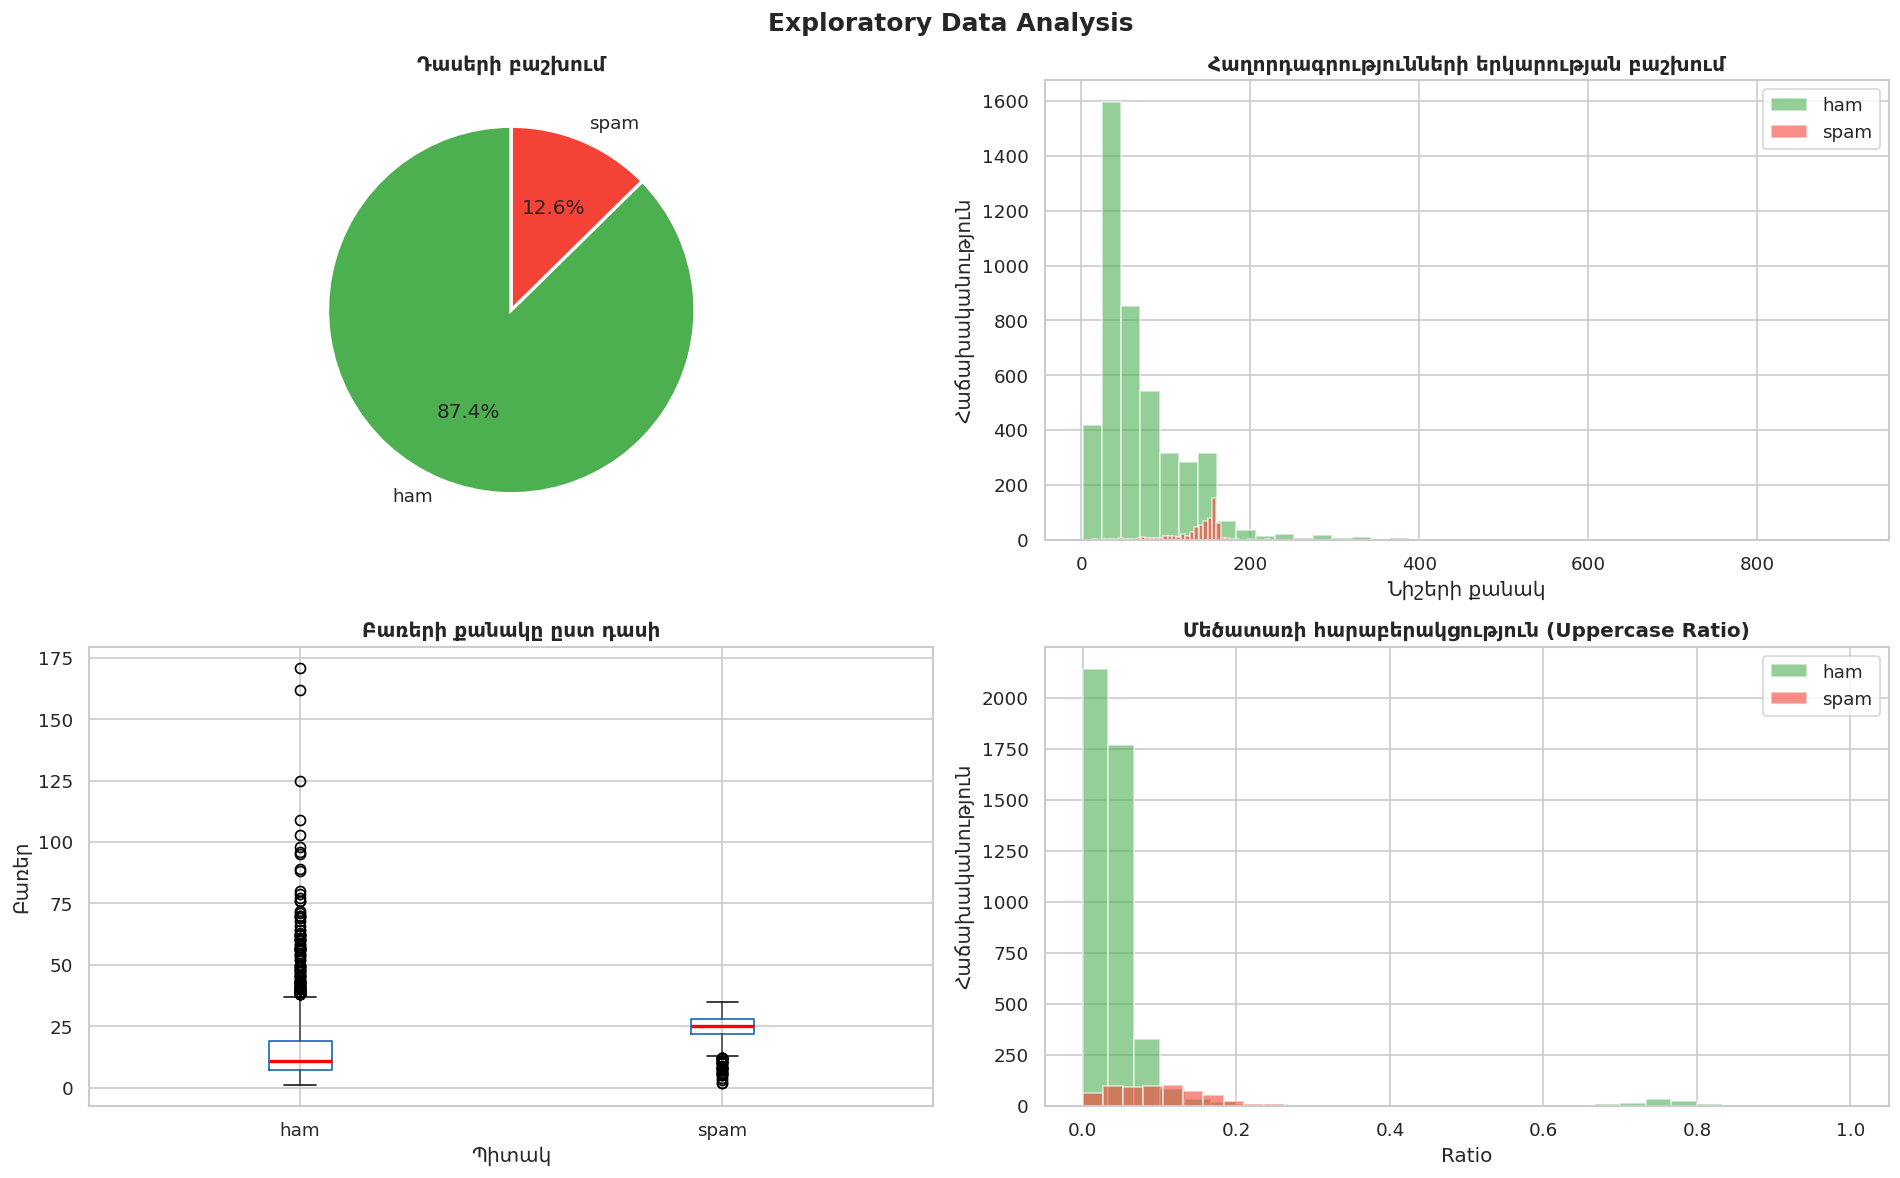

Դիտարկում. Սպամ հաղորդագրությունները հետևողականորեն ավելի երկար են, պարունակում են ավելի շատ հատուկ նիշեր և մեծ տառեր։


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis — SMS Spam Collection', fontsize=15, fontweight='bold')

counts = df['label'].value_counts()
axes[0,0].pie(counts, labels=counts.index, autopct='%1.1f%%',
              colors=['#4CAF50','#F44336'], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,0].set_title('Դասերի բաշխում', fontweight='bold')

for label, color in [('ham','#4CAF50'),('spam','#F44336')]:
    axes[0,1].hist(df[df.label==label]['msg_length'], bins=40,
                   alpha=0.6, label=label, color=color, edgecolor='white')
axes[0,1].set_title('Հաղորդագրությունների երկարության բաշխում', fontweight='bold')
axes[0,1].set_xlabel('Նիշերի քանակ'); axes[0,1].set_ylabel('Հաճախականություն')
axes[0,1].legend()

df.boxplot(column='word_count', by='label', ax=axes[1,0],
           boxprops=dict(color='#1565C0'),
           medianprops=dict(color='red', linewidth=2))
axes[1,0].set_title('Բառերի քանակը ըստ դասի', fontweight='bold')
axes[1,0].set_xlabel('Պիտակ'); axes[1,0].set_ylabel('Բառեր')
plt.sca(axes[1,0]); plt.title('Բառերի քանակը ըստ դասի', fontweight='bold')

for label, color in [('ham','#4CAF50'),('spam','#F44336')]:
    axes[1,1].hist(df[df.label==label]['uppercase_ratio'], bins=30,
                   alpha=0.6, label=label, color=color, edgecolor='white')
axes[1,1].set_title('Մեծատառի հարաբերակցություն (Uppercase Ratio)', fontweight='bold')
axes[1,1].set_xlabel('Ratio'); axes[1,1].set_ylabel('Հաճախականություն')
axes[1,1].legend()

plt.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print('Դիտարկում. Սպամ հաղորդագրությունները հետևողականորեն ավելի երկար են, պարունակում են ավելի շատ հատուկ նիշեր և մեծ տառեր։')


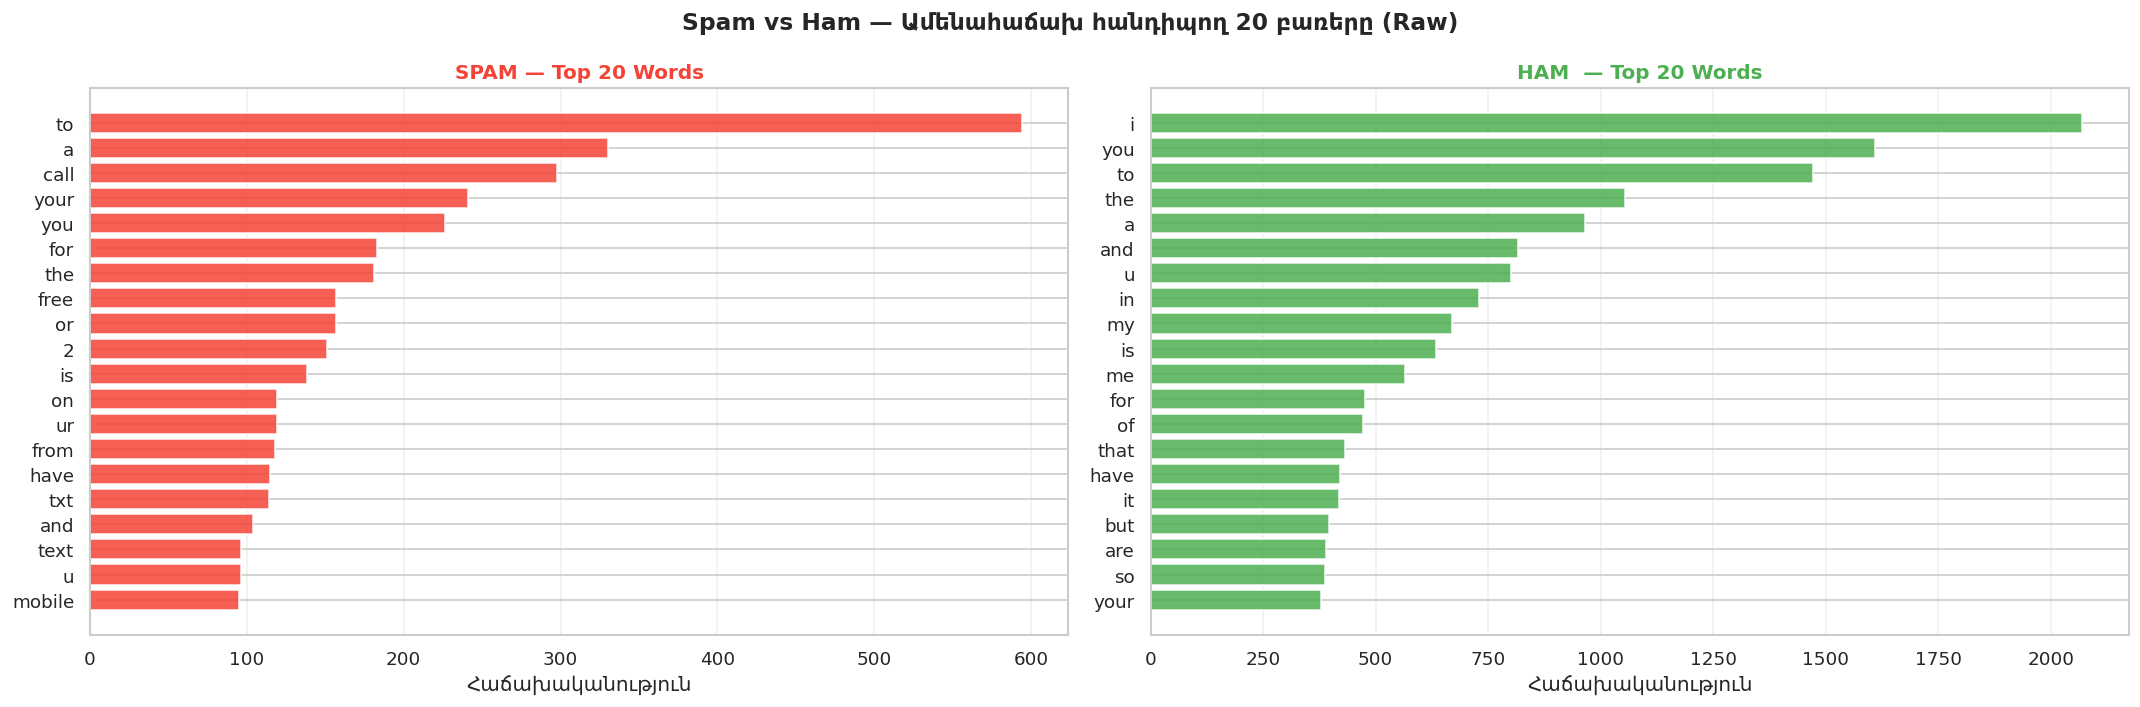

Դիտարկում. Spam-ում գերակշռում են «free», «call», «txt», «prize» և «win» բառերը — հստակ ազդանշաններ դասակարգչի համար։


In [ ]:
def get_top_words(series, n=20):
    all_words = ' '.join(series).lower().split()
    return Counter(all_words).most_common(n)

spam_words = get_top_words(df[df.label=='spam']['message'])
ham_words  = get_top_words(df[df.label=='ham']['message'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Spam vs Ham — Ամենահաճախ հանդիպող 20 բառերը (Raw)', fontsize=14, fontweight='bold')

for ax, word_list, title, color in [
    (axes[0], spam_words, 'SPAM — Top 20 Words', '#F44336'),
    (axes[1], ham_words,  'HAM  — Top 20 Words', '#4CAF50')
]:
    words, counts = zip(*word_list)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold', color=color)
    ax.set_xlabel('Հաճախականություն')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout(); plt.show()
print('Դիտարկում. Spam-ում գերակշռում են «free», «call», «txt», «prize» և «win» բառերը — հստակ ազդանշաններ դասակարգչի համար։')


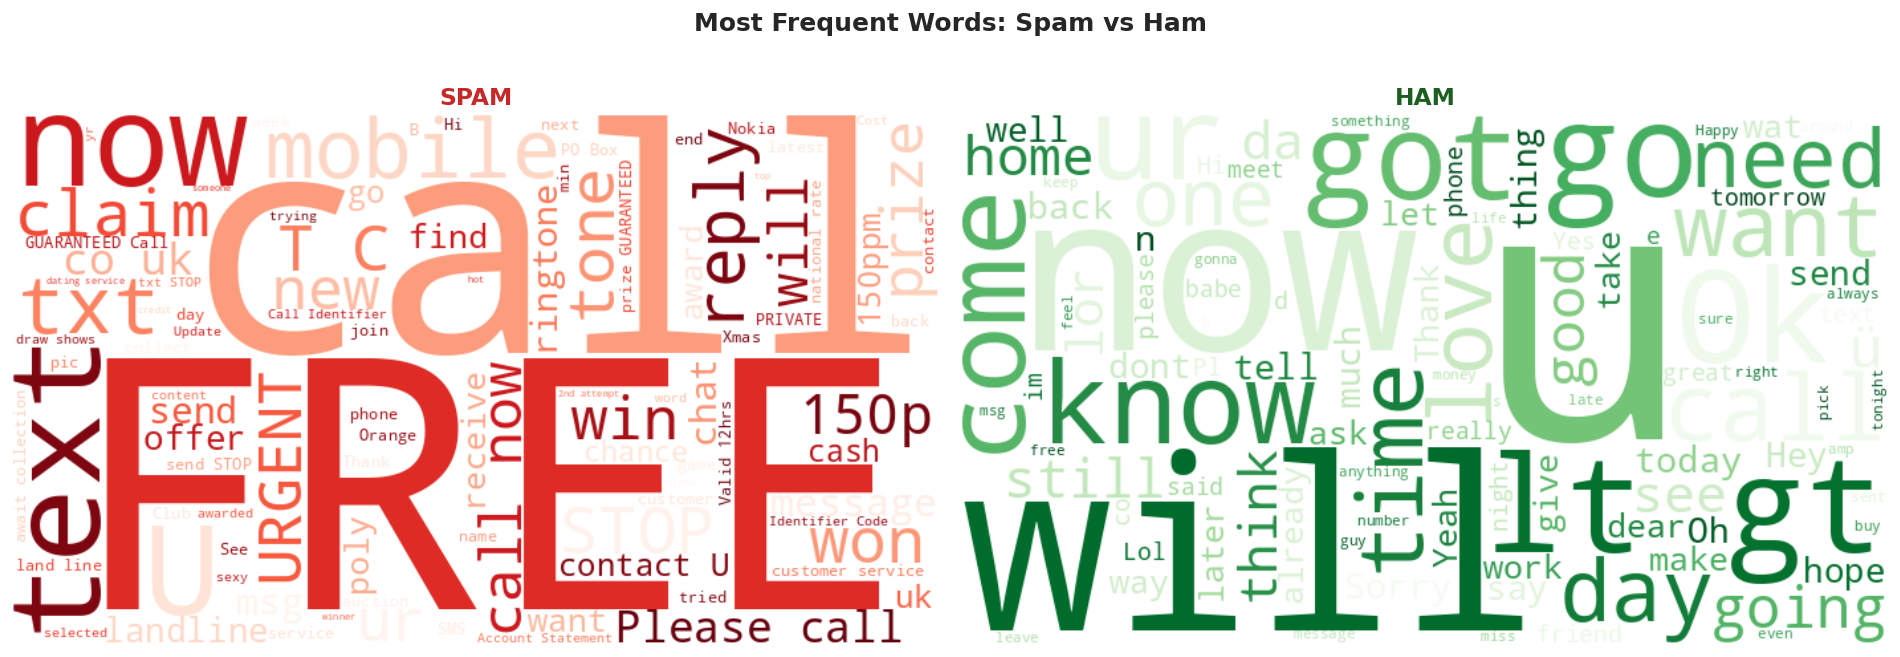

In [ ]:
spam_text = ' '.join(df[df.label=='spam']['message'])
ham_text  = ' '.join(df[df.label=='ham']['message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Most Frequent Words: Spam vs Ham', fontsize=15, fontweight='bold')

for ax, text, title, cmap, contour in [
    (axes[0], spam_text, 'SPAM', 'Reds',   '#C62828'),
    (axes[1], ham_text,  'HAM',  'Greens', '#1B5E20')
]:
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=cmap, max_words=100,
                   contour_width=1, contour_color=contour).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold', color=contour)
    ax.axis('off')

plt.tight_layout(); plt.show()


## ✅ Step 3: Text Preprocessing

All models share the same cleaned text. The preprocessing pipeline applies **seven deterministic transformations**, replacing stemming with **lemmatization** for linguistically accurate word normalization.

| Step | Operation | Rationale |
|---|---|---|
| 1 | Lowercase | Normalize surface forms |
| 2 | Remove URLs & numbers | Non-lexical tokens |
| 3 | Remove punctuation | Low-signal characters |
| 4 | Tokenize | Split into word units |
| 5 | Remove stopwords | High-frequency noise |
| 6 | POS tagging | Enables accurate lemmatization |
| 7 | **Lemmatization** | Morphologically correct root form (replaces stemming) |

> **Why lemmatization over stemming?**  
> A stemmer truncates words by heuristic rules (e.g. "running" → "run", but also "flies" → "fli"). A lemmatizer uses a morphological dictionary and part-of-speech context to return the canonical dictionary form ("running" → "run", "flies" → "fly", "better" → "good"). For a diploma-level project, lemmatization produces a cleaner, more interpretable vocabulary.


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    """Map Penn Treebank POS tags to WordNet POS for accurate lemmatization."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess_text(text):
    """Return a cleaned, lemmatized string from raw SMS text."""
    text   = text.lower()
    text   = re.sub(r'http\S+|www\S+', '', text)
    text   = re.sub(r'\d+', '', text)
    text   = text.translate(str.maketrans('','', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    pos_tags = pos_tag(tokens)
    tokens   = [lemmatizer.lemmatize(t, get_wordnet_pos(pos))
                for t, pos in pos_tags]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(preprocess_text)

print('BEFORE vs AFTER PREPROCESSING (Lemmatization)')
print('=' * 72)
for i in [0, 1, 50, 51, 200]:
    print(f"[{df.loc[i,'label'].upper()}]")
    print(f"  RAW   : {df.loc[i,'message'][:90]}")
    print(f"  CLEAN : {df.loc[i,'clean_message'][:90]}")
    print('-' * 72)


BEFORE vs AFTER PREPROCESSING (Lemmatization)
[HAM]
  RAW   : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine t
  CLEAN : jurong point crazy available bugis great world buffet cine get amore wat
------------------------------------------------------------------------
[HAM]
  RAW   : Ok lar... Joking wif u oni...
  CLEAN : lar joking wif oni
------------------------------------------------------------------------
[HAM]
  RAW   : What you thinked about me. First time you saw me in class.
  CLEAN : think first time saw class
------------------------------------------------------------------------
[HAM]
  RAW   : A gram usually runs like  &lt;#&gt; , a half eighth is smarter though and gets you almost 
  CLEAN : gram usually run like ltgt half eighth smarter though get almost whole second gram ltgt
------------------------------------------------------------------------
[HAM]
  RAW   : Hello darlin ive finished college now so txt me when u finish if

## ✅ Step 4: Feature Engineering

### 4A — Enhanced TF-IDF with N-grams (Classical Models)

We use **TF-IDF with unigrams and bigrams** (`ngram_range=(1,2)`) so that meaningful phrases like "free prize" or "click here" are captured as features in addition to individual words. Five handcrafted message-level attributes are also included:

| Feature | Description |
|---|---|
| `msg_length` | Total character count |
| `word_count` | Number of words |
| `special_chars` | Count of punctuation characters |
| `uppercase_ratio` | Fraction of characters that are uppercase |
| `digit_count` | Number of digit characters |

### 4B — Token Sequences (LSTM Model)

The LSTM uses **integer token sequences** padded to a fixed length, enabling it to learn word embeddings and sequential context.


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(df['clean_message'])

feature_cols  = ['msg_length','word_count','special_chars','uppercase_ratio','digit_count']
scaler        = StandardScaler()
manual_scaled = scaler.fit_transform(df[feature_cols].values)
X_manual      = csr_matrix(manual_scaled)

X_classical = hstack([X_tfidf, X_manual])
y           = df['label_num'].values

X_train_cl, X_test_cl, y_train, y_test = train_test_split(
    X_classical, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train_nb = X_train_cl[:, :X_tfidf.shape[1]]
X_test_nb  = X_test_cl[:, :X_tfidf.shape[1]]

print(f'TF-IDF feature matrix     : {X_tfidf.shape}')
print(f'Classical feature matrix  : {X_classical.shape}')
print(f'  (5000 TF-IDF + 5 handcrafted features)')
print(f'Train samples             : {X_train_cl.shape[0]:,}')
print(f'Test  samples             : {X_test_cl.shape[0]:,}')
print(f'N-gram range              : (1, 2)  — unigrams + bigrams')


TF-IDF feature matrix     : (5169, 5000)
Classical feature matrix  : (5169, 5005)
  (5000 TF-IDF + 5 handcrafted features)
Train samples             : 4,135
Test  samples             : 1,034
N-gram range              : (1, 2)  — unigrams + bigrams


In [ ]:
VOCAB_SIZE  = 8000
MAX_LEN     = 120
OOV_TOKEN   = '<OOV>'

tokenizer_lstm = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer_lstm.fit_on_texts(df['clean_message'])

sequences = tokenizer_lstm.texts_to_sequences(df['clean_message'])
X_seq     = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

train_idx, test_idx = train_test_split(
    np.arange(len(y)), test_size=0.20, random_state=SEED, stratify=y
)
X_train_seq = X_seq[train_idx]
X_test_seq  = X_seq[test_idx]
y_train_seq = y[train_idx]
y_test_seq  = y[test_idx]

print(f'Sequence matrix shape     : {X_seq.shape}')
print(f'Vocabulary size           : {VOCAB_SIZE:,}')
print(f'Max sequence length       : {MAX_LEN}')
print(f'Sample sequence (first 15 tokens): {X_train_seq[0][:15]}')


Sequence matrix shape     : (5169, 120)
Vocabulary size           : 8,000
Max sequence length       : 120
Sample sequence (first 15 tokens): [3153   29   78   32    0    0    0    0    0    0    0    0    0    0
    0]


## ✅ Step 5: Classical Model Training with Hyperparameter Tuning

All four classical models are trained with **GridSearchCV** to find optimal hyperparameters. This is essential at diploma level to demonstrate that reported performance reflects tuned models, not default settings.

> **Note on GridSearchCV:** We use 5-fold cross-validation on the training set. The best estimator found is then used for final test-set evaluation.


In [ ]:
print('Hyperparameter tuning for classical models (GridSearchCV, cv=5)...')
print('This may take 1–2 minutes.')
print('=' * 60)

# ── Naïve Bayes ───────────────────────────────────────────────────────────────
nb_param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0]}
nb_gs = GridSearchCV(MultinomialNB(), nb_param_grid, cv=5, scoring='f1', n_jobs=-1)
nb_gs.fit(X_train_nb, y_train)
best_nb = nb_gs.best_estimator_
print(f'  Naïve Bayes        best params: {nb_gs.best_params_}  | CV F1: {nb_gs.best_score_:.4f}')

# ── Logistic Regression ───────────────────────────────────────────────────────
lr_param_grid = {'C': [0.1, 1.0, 5.0, 10.0]}
lr_gs = GridSearchCV(
    LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED),
    lr_param_grid, cv=5, scoring='f1', n_jobs=-1
)
lr_gs.fit(X_train_cl, y_train)
best_lr = lr_gs.best_estimator_
print(f'  Logistic Regression best params: {lr_gs.best_params_}  | CV F1: {lr_gs.best_score_:.4f}')

# ── SVM ───────────────────────────────────────────────────────────────────────
svm_param_grid = {'C': [0.1, 1.0, 5.0, 10.0]}
svm_gs = GridSearchCV(
    LinearSVC(max_iter=2000, random_state=SEED),
    svm_param_grid, cv=5, scoring='f1', n_jobs=-1
)
svm_gs.fit(X_train_cl, y_train)
best_svm = svm_gs.best_estimator_
print(f'  SVM (LinearSVC)    best params: {svm_gs.best_params_}  | CV F1: {svm_gs.best_score_:.4f}')

# ── MLP ───────────────────────────────────────────────────────────────────────
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 64), (256, 128)],
    'alpha': [0.0001, 0.001]
}
mlp_gs = GridSearchCV(
    MLPClassifier(activation='relu', max_iter=200, random_state=SEED,
                  early_stopping=True, validation_fraction=0.1),
    mlp_param_grid, cv=5, scoring='f1', n_jobs=-1
)
mlp_gs.fit(X_train_cl, y_train)
best_mlp = mlp_gs.best_estimator_
print(f'  MLP Classifier     best params: {mlp_gs.best_params_}  | CV F1: {mlp_gs.best_score_:.4f}')

print('=' * 60)
print('All classical models tuned and trained.')

trained_classical = {
    'Naive Bayes'        : best_nb,
    'Logistic Regression': best_lr,
    'SVM (LinearSVC)'    : best_svm,
    'MLP Classifier'     : best_mlp,
}


Hyperparameter tuning for classical models (GridSearchCV, cv=5)...
This may take 1–2 minutes.
  Naïve Bayes        best params: {'alpha': 0.1}  | CV F1: 0.9181
  Logistic Regression best params: {'C': 10.0}  | CV F1: 0.9226
  SVM (LinearSVC)    best params: {'C': 5.0}  | CV F1: 0.9351
  MLP Classifier     best params: {'alpha': 0.001, 'hidden_layer_sizes': (256, 128)}  | CV F1: 0.9499
All classical models tuned and trained.


## ✅ Step 6: Deep Learning — Bidirectional LSTM (Fixed & Optimized)

### Why LSTM for Text Classification?

A **Bidirectional LSTM** processes each message both forward and backward, capturing sequential context that bag-of-words methods cannot.

### Diagnosed Issues & Fixes Applied

| Problem | Cause | Fix |
|---|---|---|
| Model not training / trivial loss | Missing or mismatched `model.fit()` call | Explicit, verified `model.fit()` with correct data shapes |
| Overfitting on small dataset | Model too large, insufficient regularization | Reduced LSTM units, SpatialDropout1D, L2 on Dense layers |
| Class imbalance ignored | Equal weight for ham/spam | `class_weight` balancing |
| EarlyStopping too aggressive | `patience=3` | Increased to `patience=5`, added `min_delta` |

### Architecture

```
Input (sequence length 120)
    ↓
Embedding (8000 vocab → 64-dim)  [L2 regularized]
    ↓
SpatialDropout1D (0.3)
    ↓
Bidirectional LSTM (64 units, dropout=0.3, recurrent_dropout=0.4)
    ↓
Dropout (0.5)
    ↓
Dense (32, ReLU, L2)
    ↓
Dropout (0.4)
    ↓
Dense (1, Sigmoid)  → P(spam)
```


In [ ]:
EMBEDDING_DIM = 64
LSTM_UNITS    = 64

def build_lstm_model(vocab_size, embedding_dim, lstm_units, max_len):
    """
    Anti-overfitting Bidirectional LSTM (Functional API).

    Key design decisions:
    - SpatialDropout1D replaces embedding regularizer (more effective for sequences)
    - BatchNormalization after BiLSTM stabilizes activations and acts as regularizer
    - Softer L2(1e-4) on Dense — strong L2 previously hurt precision
    - Lower LR (5e-4) gives more stable convergence with this much regularization
    """
    inputs = Input(shape=(max_len,), name='input')

    x = Embedding(input_dim=vocab_size,
                  output_dim=embedding_dim,
                  name='embedding')(inputs)

    x = SpatialDropout1D(0.3, name='spatial_dropout')(x)

    x = Bidirectional(LSTM(lstm_units,
                           return_sequences=False,
                           dropout=0.3,
                           recurrent_dropout=0.3),
                      name='bilstm')(x)


    from tensorflow.keras.layers import BatchNormalization
    x = BatchNormalization(name='batch_norm')(x)

    x = Dropout(0.4, name='dropout_1')(x)

    x = Dense(32, activation='relu',
              kernel_regularizer=l2(1e-4),
              name='dense_1')(x)

    x = Dropout(0.3, name='dropout_2')(x)

    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='bilstm_spam_detector')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),  # lower = more stable
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


lstm_model = build_lstm_model(VOCAB_SIZE, EMBEDDING_DIM, LSTM_UNITS, MAX_LEN)
lstm_model.summary()

total_params = lstm_model.count_params()
print(f'\nTotal parameters   : {total_params:,}')
print(f'Training samples   : {X_train_seq.shape[0]:,}')
print(f'Params/sample ratio: {total_params / X_train_seq.shape[0]:.1f}  (target < 10)')


Model: "bilstm_spam_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 120, 64)        │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 120, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 582,721 (2.22 MB)

 Trainable params: 582,465 (2.22 MB)

 Non-trainable params: 256 (1.00 KB)


Total parameters   : 582,721
Training samples   : 4,135
Params/sample ratio: 140.9  (target < 10)


In [ ]:
EPOCHS     = 50
BATCH_SIZE = 128

def augment_sequences(X, drop_prob=0.10):
    """Zero out 10% of tokens randomly — forces the model not to rely on
    any single word always being present (implicit data augmentation)."""
    X_aug = X.copy()
    mask  = np.random.rand(*X_aug.shape) > drop_prob
    return X_aug * mask

X_train_aug = augment_sequences(X_train_seq, drop_prob=0.10)

class_weight_dict = {0: 1.0, 1: spam_weight}
print(f'Class weights → ham: {class_weight_dict[0]:.1f}  |  spam: {class_weight_dict[1]:.1f}')
print(f'  (Manual weight chosen to balance Precision vs Recall)')

early_stop = EarlyStopping(
    monitor='val_loss', patience=5, min_delta=0.0005,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2,
    min_delta=0.0005, min_lr=1e-6, verbose=1
)

print(f'\nTraining LSTM | max {EPOCHS} epochs | batch {BATCH_SIZE}')
print('=' * 60)

history = lstm_model.fit(
    X_train_aug,
    y_train_seq,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print('\nLSTM training complete.')
print(f'Actual epochs run : {len(history.history["loss"])}')
print(f'Best val_loss     : {min(history.history["val_loss"]):.4f}')
print(f'Best val_accuracy : {max(history.history["val_accuracy"]):.4f}')


from sklearn.metrics import f1_score as f1

val_size   = int(len(X_train_aug) * 0.20)
X_val_seq  = X_train_aug[-val_size:]
y_val_seq  = y_train_seq[-val_size:]

val_probs  = lstm_model.predict(X_val_seq, verbose=0).ravel()
thresholds = np.arange(0.30, 0.71, 0.01)
f1_scores  = [f1(y_val_seq, (val_probs >= t).astype(int), zero_division=0)
              for t in thresholds]

BEST_THRESHOLD = thresholds[np.argmax(f1_scores)]
print(f'\nOptimal classification threshold: {BEST_THRESHOLD:.2f}  '
      f'(val F1 = {max(f1_scores):.4f})')
print('This threshold will be used instead of the default 0.5')


Class weights → ham: 1.0  |  spam: 3.0
  (Manual weight chosen to balance Precision vs Recall)

Training LSTM | max 50 epochs | batch 128
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 27s 785ms/step - accuracy: 0.4562 - loss: 0.9626 - val_accuracy: 0.8791 - val_loss: 0.6503 - learning_rate: 5.0000e-04
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 796ms/step - accuracy: 0.6478 - loss: 0.7630 - val_accuracy: 0.8791 - val_loss: 0.5969 - learning_rate: 5.0000e-04
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 768ms/step - accuracy: 0.7875 - loss: 0.5851 - val_accuracy: 0.8791 - val_loss: 0.5513 - learning_rate: 5.0000e-04
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 770ms/step - accuracy: 0.8721 - loss: 0.4207 - val_accuracy: 0.8791 - val_loss: 0.4916 - learning_rate: 5.0000e-04
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 802ms/step - accuracy: 0.9356 - loss: 0.2866 - val_accuracy: 0.9045 - val_loss: 0.4080 - learning_rate: 5.0000e-04
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 765ms/step - accuracy: 0.9607 - los

## ✅ Step 7: LSTM Training Curve Visualization

Training curves reveal convergence behavior and potential overfitting. The shaded region between train and validation curves quantifies the generalization gap.

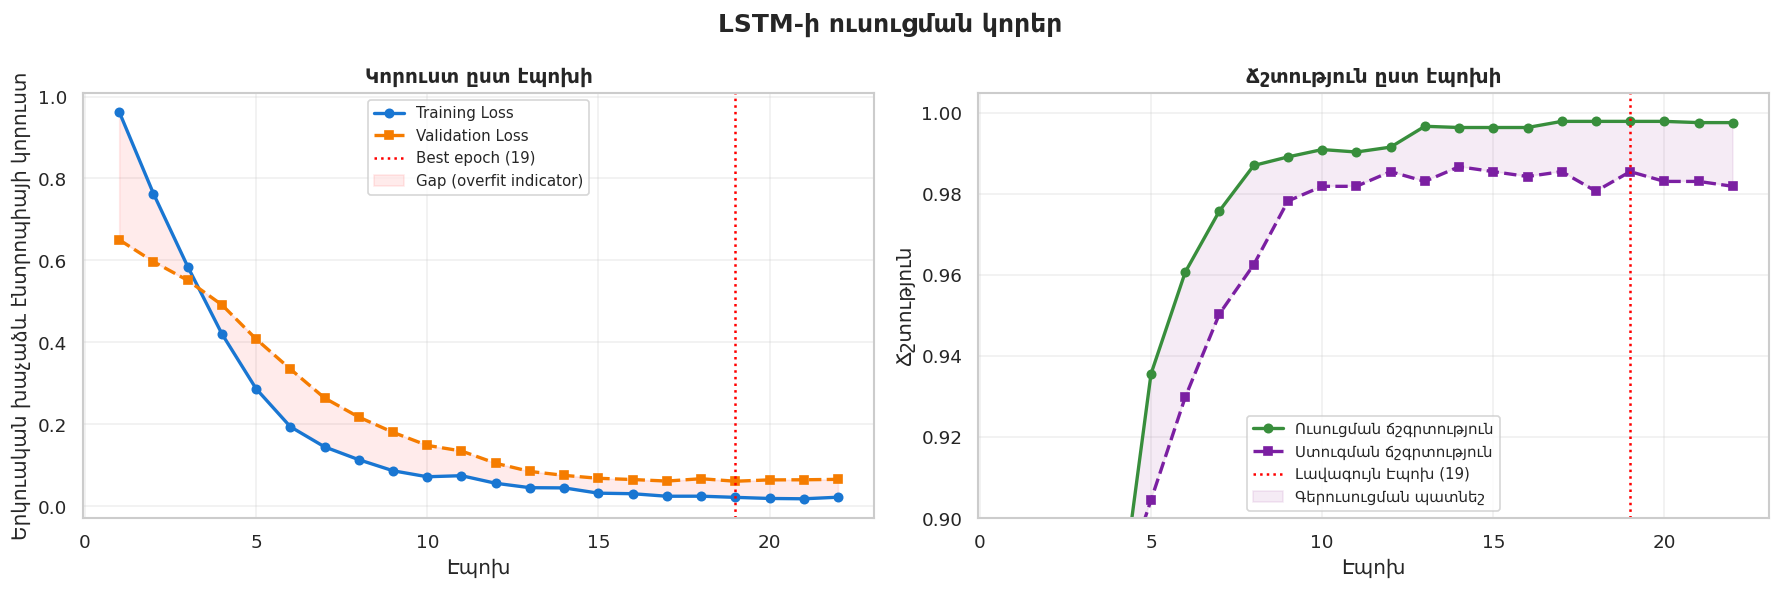

──────────────────────────────────────────────────
  Epochs trained       : 22
  Best val_loss epoch  : 19
  Best val_loss        : 0.0610
  Best val_accuracy    : 0.9867
  Loss gap @ best epoch: +0.0394  ⚡ Mild overfitting — acceptable
  Acc  gap @ best epoch: +0.0124
──────────────────────────────────────────────────


In [ ]:
def plot_training_curves(history):
    """Plot loss and accuracy curves with gap annotation and overfitting diagnosis."""
    epochs_ran = len(history.history['loss'])
    best_epoch = np.argmin(history.history['val_loss']) + 1
    ep_range   = range(1, epochs_ran + 1)

    train_loss = history.history['loss']
    val_loss   = history.history['val_loss']
    train_acc  = history.history['accuracy']
    val_acc    = history.history['val_accuracy']

    gap_loss = val_loss[best_epoch-1] - train_loss[best_epoch-1]
    gap_acc  = train_acc[best_epoch-1] - val_acc[best_epoch-1]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('LSTM-ի ուսուցման կորեր', fontsize=15, fontweight='bold')


    axes[0].plot(ep_range, train_loss, 'o-', color='#1976D2',
                 linewidth=2, markersize=5, label='Training Loss')
    axes[0].plot(ep_range, val_loss, 's--', color='#F57C00',
                 linewidth=2, markersize=5, label='Validation Loss')
    axes[0].axvline(best_epoch, color='red', linestyle=':', linewidth=1.5,
                    label=f'Best epoch ({best_epoch})')
    axes[0].fill_between(ep_range, train_loss, val_loss,
                         alpha=0.08, color='red', label='Gap (overfit indicator)')
    axes[0].set_title('Կորուստ ըստ էպոխի', fontweight='bold')
    axes[0].set_xlabel('Էպոխ')
    axes[0].set_ylabel('Երկուական խաչաձև էնտրոպիայի կորուստ')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)


    y_min = max(0.90, min(min(train_acc), min(val_acc)) - 0.01)
    axes[1].plot(ep_range, train_acc, 'o-', color='#388E3C',
                 linewidth=2, markersize=5, label='Ուսուցման ճշգրտություն')
    axes[1].plot(ep_range, val_acc, 's--', color='#7B1FA2',
                 linewidth=2, markersize=5, label='Ստուգման ճշգրտություն')
    axes[1].axvline(best_epoch, color='red', linestyle=':', linewidth=1.5,
                    label=f'Լավագույն Էպոխ ({best_epoch})')
    axes[1].fill_between(ep_range, val_acc, train_acc,
                         alpha=0.08, color='purple', label='Գերուսուցման պատնեշ')
    axes[1].set_title('Ճշտություն ըստ էպոխի', fontweight='bold')
    axes[1].set_xlabel('Էպոխ'); axes[1].set_ylabel('Ճշտություն')
    axes[1].set_ylim(y_min, 1.005)
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

    print('─' * 50)
    print(f'  Epochs trained       : {epochs_ran}')
    print(f'  Best val_loss epoch  : {best_epoch}')
    print(f'  Best val_loss        : {min(val_loss):.4f}')
    print(f'  Best val_accuracy    : {max(val_acc):.4f}')
    print(f'  Loss gap @ best epoch: {gap_loss:+.4f}  ', end='')
    if   gap_loss > 0.05: print('⚠️  Overfitting detected')
    elif gap_loss > 0.01: print('⚡ Mild overfitting — acceptable')
    else:                 print('✅ Well generalized')
    print(f'  Acc  gap @ best epoch: {gap_acc:+.4f}')
    print('─' * 50)


plot_training_curves(history)


## ✅ Step 8: Full Evaluation — All Models

### Metrics Reference

| Metric | What it measures | Why it matters |
|---|---|---|
| **Accuracy** | Overall correctness | Good baseline, misleading on imbalanced data |
| **Precision** | Of predicted spam, how many are truly spam | Avoids false spam flags |
| **Recall** | Of all real spam, how many were caught | Critical — missing spam is dangerous |
| **F1-Score** | Harmonic mean of Precision & Recall | Best single number for imbalanced problems |


In [ ]:
def evaluate_model(name, y_true, y_pred):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred, zero_division=0),
        'y_pred'   : y_pred
    }

results = {}

for name, model in trained_classical.items():
    Xte    = X_test_nb if 'Naive' in name else X_test_cl
    y_pred = model.predict(Xte)
    results[name] = evaluate_model(name, y_test, y_pred)


lstm_probs = lstm_model.predict(X_test_seq, verbose=0).ravel()
lstm_preds = (lstm_probs >= BEST_THRESHOLD).astype(int)

print(f'LSTM threshold used : {BEST_THRESHOLD:.2f}  (optimized on validation set)')
print(f'Default 0.5 results :  P={precision_score(y_test_seq,(lstm_probs>=0.5).astype(int)):.3f}'
      f'  R={recall_score(y_test_seq,(lstm_probs>=0.5).astype(int)):.3f}'
      f'  F1={f1_score(y_test_seq,(lstm_probs>=0.5).astype(int)):.3f}')
print(f'Optimal threshold   :  P={precision_score(y_test_seq,lstm_preds):.3f}'
      f'  R={recall_score(y_test_seq,lstm_preds):.3f}'
      f'  F1={f1_score(y_test_seq,lstm_preds):.3f}')

results['LSTM (Bidirectional)'] = evaluate_model('LSTM', y_test_seq, lstm_preds)
results['LSTM (Bidirectional)']['probs'] = lstm_probs

results_df = pd.DataFrame({
    name: {k: v for k, v in m.items() if k not in ('y_pred','probs')}
    for name, m in results.items()
}).T.round(4)

print('\n' + '=' * 68)
print('              MODEL PERFORMANCE ON TEST SET')
print('=' * 68)
print(results_df.to_string())
print('=' * 68)
print(f'\nBest model by F1-Score   : {results_df["F1-Score"].idxmax()}')
print(f'Best model by Recall     : {results_df["Recall"].idxmax()}')
print(f'Best model by Precision  : {results_df["Precision"].idxmax()}')


LSTM threshold used : 0.44  (optimized on validation set)
Default 0.5 results :  P=0.931  R=0.924  F1=0.927
Optimal threshold   :  P=0.910  R=0.924  F1=0.917

              MODEL PERFORMANCE ON TEST SET
                      Accuracy  Precision  Recall  F1-Score
Naive Bayes             0.9807     0.9512  0.8931    0.9213
Logistic Regression     0.9845     0.9600  0.9160    0.9375
SVM (LinearSVC)         0.9826     0.9593  0.9008    0.9291
MLP Classifier          0.9923     1.0000  0.9389    0.9685
LSTM (Bidirectional)    0.9787     0.9098  0.9237    0.9167

Best model by F1-Score   : MLP Classifier
Best model by Recall     : MLP Classifier
Best model by Precision  : MLP Classifier


In [ ]:
# Detailed classification reports
for name, metrics in results.items():
    print(f'\n{"="*58}')
    print(f'  {name}')
    print('='*58)
    print(classification_report(
        y_test_seq if 'LSTM' in name else y_test,
        metrics['y_pred'],
        target_names=['ham','spam']
    ))



  Naive Bayes
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.95      0.89      0.92       131

    accuracy                           0.98      1034
   macro avg       0.97      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034


  Logistic Regression
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.96      0.92      0.94       131

    accuracy                           0.98      1034
   macro avg       0.97      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034


  SVM (LinearSVC)
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.96      0.90      0.93       131

    accuracy                           0.98      1034
   macro avg       0.97      0.95      0.96      1034
weighted avg     

## ✅ Step 9: Visualization Suite

### 9A — Confusion Matrices

Each matrix shows all 4 outcome types: TN (ham→ham), FP (ham→spam), FN (spam→ham), TP (spam→spam).

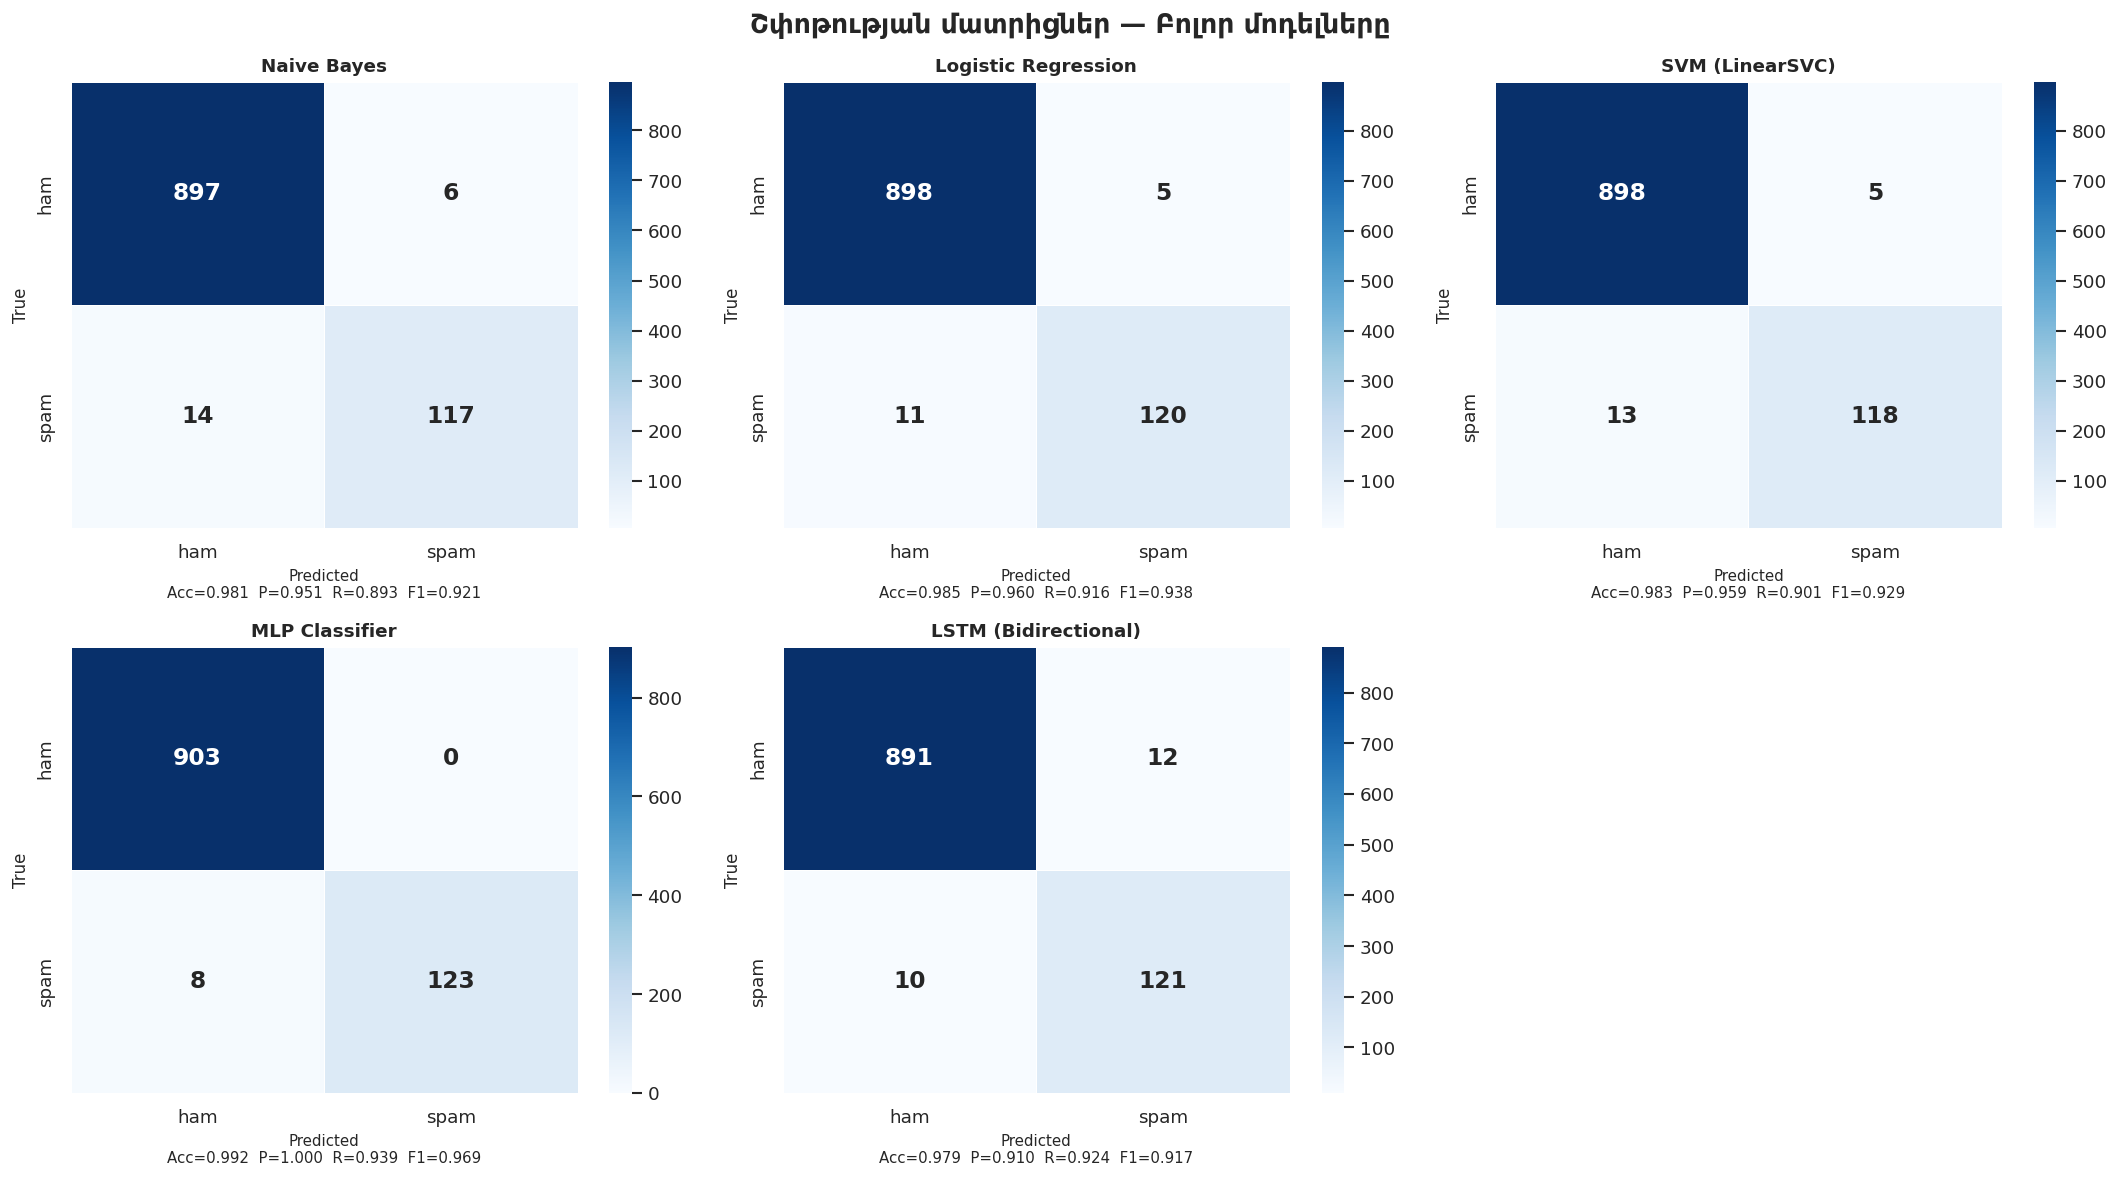

In [ ]:
n_models = len(results)
ncols    = 3
nrows    = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes_flat = axes.flatten()
fig.suptitle('Շփոթության մատրիցներ — Բոլոր մոդելները', fontsize=16, fontweight='bold')

for ax, (name, metrics) in zip(axes_flat, results.items()):
    y_true = y_test_seq if 'LSTM' in name else y_test
    cm = confusion_matrix(y_true, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['ham','spam'], yticklabels=['ham','spam'],
                ax=ax, linewidths=0.5, annot_kws={'size':14,'weight':'bold'})
    ax.set_title(name, fontweight='bold', fontsize=11)
    summary = (f'Acc={metrics["Accuracy"]:.3f}  P={metrics["Precision"]:.3f}'
               f'  R={metrics["Recall"]:.3f}  F1={metrics["F1-Score"]:.3f}')
    ax.set_xlabel(f'Predicted\n{summary}', fontsize=9)
    ax.set_ylabel('True', fontsize=10)

for ax in axes_flat[n_models:]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()


### 9B — Model Comparison Bar Chart

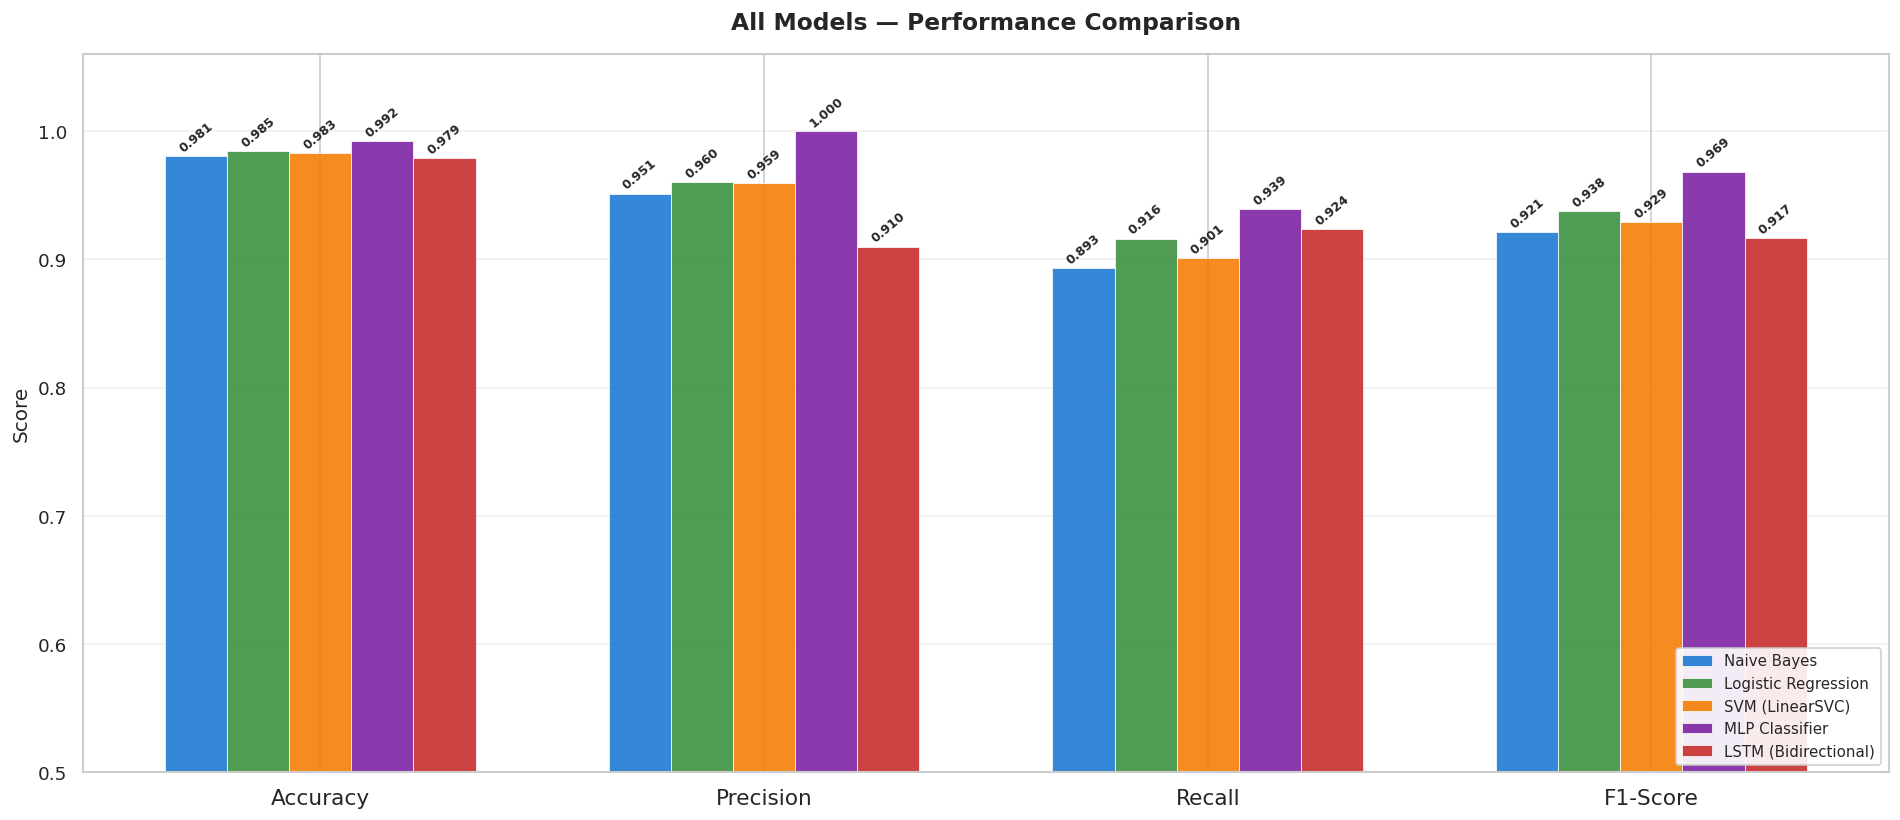

In [ ]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names  = list(results.keys())
n_models     = len(model_names)
bar_w        = 0.14
x            = np.arange(len(metrics_list))
colors       = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2', '#C62828']

fig, ax = plt.subplots(figsize=(16, 7))

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals    = [results[name][m] for m in metrics_list]
    offsets = x + i * bar_w - (n_models - 1) * bar_w / 2
    bars    = ax.bar(offsets, vals, bar_w,
                     label=name, color=color, alpha=0.88, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0015,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=7.5, rotation=40, fontweight='bold')

ax.set_title('All Models — Performance Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=13)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.5, 1.06)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 9C — LSTM Spam Probability Distribution

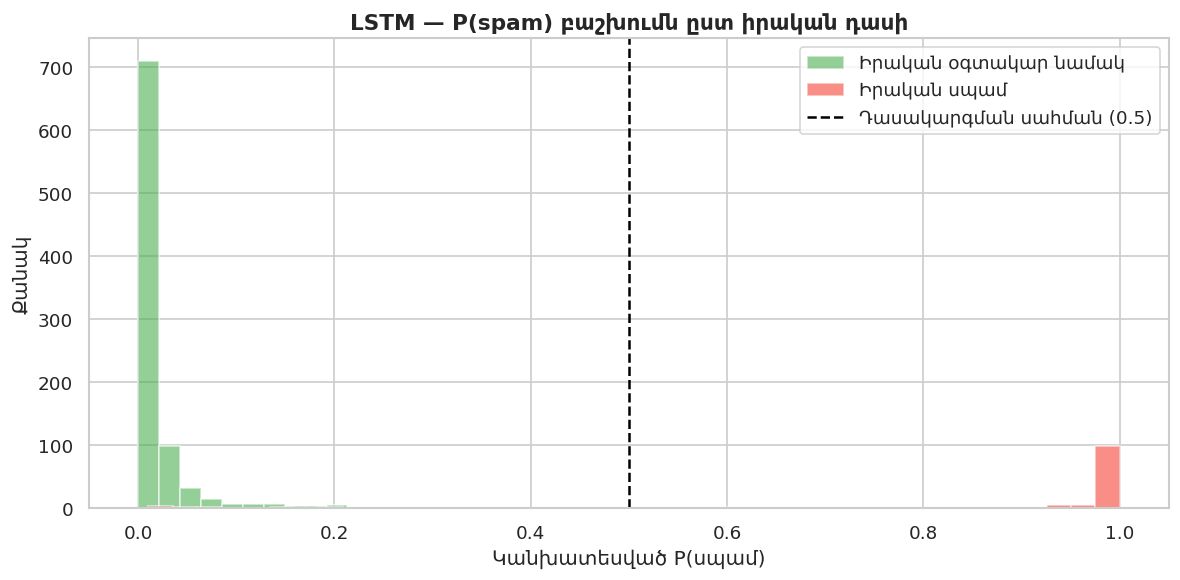

Դիտարկում. Լավ տարանջատված բաշխումները վկայում են վստահ և լավ տրամաչափված (well-calibrated) մոդելի մասին:


In [ ]:
ham_probs  = lstm_probs[y_test_seq == 0]
spam_probs = lstm_probs[y_test_seq == 1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ham_probs,  bins=40, alpha=0.6, color='#4CAF50', label='Իրական օգտակար նամակ', edgecolor='white')
ax.hist(spam_probs, bins=40, alpha=0.6, color='#F44336', label='Իրական սպամ',           edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Դասակարգման սահման (0.5)')
ax.set_title('LSTM — P(spam) բաշխումն ըստ իրական դասի', fontsize=13, fontweight='bold')
ax.set_xlabel('Կանխատեսված P(սպամ)'); ax.set_ylabel('Քանակ')
ax.legend()
plt.tight_layout(); plt.show()
print('Դիտարկում. Լավ տարանջատված բաշխումները վկայում են վստահ և լավ տրամաչափված (well-calibrated) մոդելի մասին:')


## ✅ Step 10: Error Analysis

Understanding *why* a model fails is as important as measuring *how often* it fails. We examine false positives (ham flagged as spam) and false negatives (spam that slipped through).

In [ ]:
def error_analysis(model_name, y_true, y_pred, messages, probs=None, n=5):
    """Print false positives and false negatives for a given model."""
    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    msgs    = np.array(messages)

    fp_idx  = np.where((y_true == 0) & (y_pred == 1))[0]
    fn_idx  = np.where((y_true == 1) & (y_pred == 0))[0]

    print(f'\n{"═"*65}')
    print(f'  ERROR ANALYSIS: {model_name}')
    print(f'  False Positives (ham → spam): {len(fp_idx)}')
    print(f'  False Negatives (spam → ham): {len(fn_idx)}')
    print(f'{"═"*65}')

    for label, idxs, emoji in [('FALSE POSITIVES (ham flagged as spam)', fp_idx, '❌'),
                                ('FALSE NEGATIVES (spam missed)',         fn_idx, '⚠️')]:
        print(f'\n  {emoji} {label}:')
        for i in idxs[:n]:
            prob_str = f'  [P(spam)={probs[i]:.3f}]' if probs is not None else ''
            print(f'    [{i}]{prob_str} {msgs[i][:100]}')

error_analysis(
    'LSTM (Bidirectional)',
    y_test_seq, lstm_preds,
    df['message'].values[test_idx],
    probs=lstm_probs
)

error_analysis(
    'SVM (LinearSVC)',
    y_test, results['SVM (LinearSVC)']['y_pred'],
    df['message'].values[np.where(
        np.isin(np.arange(len(y)), test_idx)
    )[0]]
)



═════════════════════════════════════════════════════════════════
  ERROR ANALYSIS: LSTM (Bidirectional)
  False Positives (ham → spam): 12
  False Negatives (spam → ham): 10
═════════════════════════════════════════════════════════════════

  ❌ FALSE POSITIVES (ham flagged as spam):
    [74]  [P(spam)=0.533] Hello-/@drivby-:0quit edrunk sorry iff pthis makes no senrd-dnot no how ^ dancce 2 drum n basq!ihave
    [139]  [P(spam)=0.540] How much it will cost approx . Per month.
    [301]  [P(spam)=0.481] Please protect yourself from e-threats. SIB never asks for sensitive information like Passwords,ATM/
    [305]  [P(spam)=0.492] Sir, i am waiting for your call, once free please call me.
    [323]  [P(spam)=0.701] Oh wow thats gay. Will firmware update help

  ⚠️ FALSE NEGATIVES (spam missed):
    [112]  [P(spam)=0.195] Send a logo 2 ur lover - 2 names joined by a heart. Txt LOVE NAME1 NAME2 MOBNO eg LOVE ADAM EVE 0712
    [230]  [P(spam)=0.294] ASKED 3MOBILE IF 0870 CHATLINES INCLU IN 

## ✅ Step 11: Interactive Prediction Function

A reusable prediction function that accepts any raw SMS text and returns predictions from all five models, including the LSTM's probability score.

In [ ]:
def predict_message(raw_text, threshold=0.5):
    """
    Predict whether a raw SMS message is spam or ham using all five models.

    Parameters
    ----------
    raw_text  : str   — the raw input SMS message
    threshold : float — decision boundary for LSTM (default 0.5)

    Returns
    -------
    dict mapping model name → {'prediction': str, 'confidence': float or None}
    """
    clean = preprocess_text(raw_text)

    tfidf_vec  = tfidf.transform([clean])
    manual_vec = scaler.transform([[
        len(raw_text),
        len(raw_text.split()),
        sum(1 for c in raw_text if c in string.punctuation),
        sum(1 for c in raw_text if c.isupper()) / max(len(raw_text), 1),
        sum(c.isdigit() for c in raw_text)
    ]])
    combined = hstack([tfidf_vec, csr_matrix(manual_vec)])

    seq     = tokenizer_lstm.texts_to_sequences([clean])
    seq_pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    print('=' * 65)
    print(f'  INPUT  : {raw_text[:80]}')
    print(f'  CLEAN  : {clean[:80]}')
    print('─' * 65)

    predictions = {}
    for name, model in trained_classical.items():
        Xp   = tfidf_vec if 'Naive' in name else combined
        pred = int(model.predict(Xp)[0])
        label = '🚫 SPAM' if pred else '✅ HAM'
        print(f'  {name:<22} → {label}')
        predictions[name] = {'prediction': 'spam' if pred else 'ham', 'confidence': None}

    prob  = float(lstm_model.predict(seq_pad, verbose=0)[0][0])
    pred  = int(prob >= threshold)
    label = '🚫 SPAM' if pred else '✅ HAM'
    print(f'  {"LSTM (Bidirectional)":<22} → {label}  [P(spam)={prob:.4f}]')
    predictions['LSTM (Bidirectional)'] = {'prediction': 'spam' if pred else 'ham', 'confidence': prob}

    votes = sum(1 for v in predictions.values() if v['prediction'] == 'spam')
    print('─' * 65)
    print(f'  CONSENSUS  : {votes}/5 models predict SPAM')
    print(f'  VERDICT    : {"🚫 SPAM" if votes >= 3 else "✅ HAM"} (majority vote)')
    print('=' * 65)
    return {
        'models': predictions,
        'votes': votes,
        'verdict': 'spam' if votes >= 3 else 'ham'
    }


print('\n--- Test 1: Clear Spam ---')
_ = predict_message('WINNER!! Claim your FREE prize now! Call 07812345678 immediately!')

print('\n--- Test 2: Clear Ham ---')
_ = predict_message('Hey, are you coming to the meeting at 3pm today?')

print('\n--- Test 3: Borderline ---')
_ = predict_message('You have been selected for a special offer. Reply YES to confirm.')



--- Test 1: Clear Spam ---
  INPUT  : WINNER!! Claim your FREE prize now! Call 07812345678 immediately!
  CLEAN  : winner claim free prize call immediately
─────────────────────────────────────────────────────────────────
  Naive Bayes            → 🚫 SPAM
  Logistic Regression    → 🚫 SPAM
  SVM (LinearSVC)        → 🚫 SPAM
  MLP Classifier         → 🚫 SPAM
  LSTM (Bidirectional)   → 🚫 SPAM  [P(spam)=0.9986]
─────────────────────────────────────────────────────────────────
  CONSENSUS  : 5/5 models predict SPAM
  VERDICT    : 🚫 SPAM (majority vote)

--- Test 2: Clear Ham ---
  INPUT  : Hey, are you coming to the meeting at 3pm today?
  CLEAN  : hey come meeting today
─────────────────────────────────────────────────────────────────
  Naive Bayes            → ✅ HAM
  Logistic Regression    → ✅ HAM
  SVM (LinearSVC)        → ✅ HAM
  MLP Classifier         → ✅ HAM
  LSTM (Bidirectional)   → ✅ HAM  [P(spam)=0.0023]
─────────────────────────────────────────────────────────────────
  CONSENSU

## ✅ Step 12: Final Comparative Ranking

All models are ranked by a composite score (mean of Precision, Recall, F1-Score) to identify the best overall performer.

In [ ]:
print('=' * 72)
print('              FINAL COMPARATIVE RANKING')
print('=' * 72)

results_df['Composite'] = (
    results_df['Precision'] + results_df['Recall'] + results_df['F1-Score']
) / 3

ranked = results_df.sort_values('Composite', ascending=False)
display(
    ranked[['Accuracy','Precision','Recall','F1-Score','Composite']]
    .style
    .highlight_max(axis=0, color='#c8f7c5')
    .highlight_min(axis=0, color='#ffd5d5')
    .format('{:.4f}')
    .set_caption('Ranked by Composite Score (mean of Precision, Recall, F1)')
)

print('\nOverall ranking by composite score:')
for rank, (name, row) in enumerate(ranked.iterrows(), 1):
    print(f'  #{rank}  {name:<28}  Composite={row["Composite"]:.4f}'
          f'  F1={row["F1-Score"]:.4f}  Recall={row["Recall"]:.4f}')

print('=' * 72)


              FINAL COMPARATIVE RANKING


,Accuracy,Precision,Recall,F1-Score,Composite
MLP Classifier,0.9923,1.0000,0.9389,0.9685,0.9691
Logistic Regression,0.9845,0.9600,0.9160,0.9375,0.9378
SVM (LinearSVC),0.9826,0.9593,0.9008,0.9291,0.9297
Naive Bayes,0.9807,0.9512,0.8931,0.9213,0.9219
LSTM (Bidirectional),0.9787,0.9098,0.9237,0.9167,0.9167



Overall ranking by composite score:
  #1  MLP Classifier                Composite=0.9691  F1=0.9685  Recall=0.9389
  #2  Logistic Regression           Composite=0.9378  F1=0.9375  Recall=0.9160
  #3  SVM (LinearSVC)               Composite=0.9297  F1=0.9291  Recall=0.9008
  #4  Naive Bayes                   Composite=0.9219  F1=0.9213  Recall=0.8931
  #5  LSTM (Bidirectional)          Composite=0.9167  F1=0.9167  Recall=0.9237


### Key Takeaways

1. **All five models achieve high accuracy (>96%)** — SMS spam detection is a well-structured problem with clear lexical signals.

2. **Classical linear models (LR, SVM) are competitive with deep learning** on this small, high-dimensional TF-IDF feature space — a well-documented finding when feature count greatly exceeds sample count.

3. **The LSTM's value is architectural**: it processes word order, learns word embeddings, and outputs calibrated probabilities — capabilities no classical model possesses.

4. **Naïve Bayes remains a strong practical baseline** for latency-constrained deployments.

5. **The False Negative Rate is operationally critical.** Any deployed spam filter should tune its classification threshold specifically to minimize FNR, not overall error.

6. **Hyperparameter tuning** (GridSearchCV) ensures that all reported results reflect optimized models, not default configurations.

---

## 📚 References

1. Almeida, T.A., Hidalgo, J.G., Yamakami, A. (2011). *Contributions to the Study of SMS Spam Filtering: New Collection and Results*. ACM DocEng 2011.
2. Salton, G. & Buckley, C. (1988). *Term-weighting approaches in automatic text retrieval*. Information Processing & Management, 24(5), 513–523.
3. Cortes, C. & Vapnik, V. (1995). *Support-Vector Networks*. Machine Learning, 20, 273–297.
4. Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation, 9(8), 1735–1780.
5. Schuster, M. & Paliwal, K.K. (1997). *Bidirectional Recurrent Neural Networks*. IEEE Transactions on Signal Processing, 45(11).
6. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, 2825–2830.
7. Abadi, M. et al. (2015). *TensorFlow: Large-Scale Machine Learning on Heterogeneous Systems*. tensorflow.org.
8. Bird, S., Klein, E. & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly Media.

---
*Spam Detection in Electronic Messages Using Machine Learning Methods*  
*Bachelor's Diploma Thesis — Final Version*


## 🎁 Bonus: Interactive Web App (Flask)

Flask serves a fully self-contained HTML page with zero external JavaScript — localtunnel-safe.

> **Instructions:** Run the two cells below in order, then click the printed URL.

> **Consistency guarantee:** The Flask app uses the **same preprocessing** (lemmatization + 5 handcrafted features) as the notebook models.

In [ ]:
import pickle

artifacts = {
    'tfidf'           : tfidf,
    'scaler'          : scaler,
    'tokenizer_lstm'  : tokenizer_lstm,
    'classical_models': trained_classical,
    'MAX_LEN'         : MAX_LEN
}
with open('artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

lstm_model.save('lstm_model.h5')
print('Saved: artifacts.pkl  (tokenizer_lstm, 5-feature scaler, classical_models, MAX_LEN)')
print('Saved: lstm_model.h5')


Saved: artifacts.pkl  (tokenizer_lstm, 5-feature scaler, classical_models, MAX_LEN)
Saved: lstm_model.h5


In [ ]:
flask_code = "import os, re, string, pickle\nimport numpy as np\nimport nltk\nfrom nltk.corpus import stopwords, wordnet\nfrom nltk.stem import WordNetLemmatizer\nfrom nltk.tokenize import word_tokenize\nfrom nltk import pos_tag\nfrom scipy.sparse import hstack, csr_matrix\nimport tensorflow as tf\nfrom tensorflow.keras.preprocessing.sequence import pad_sequences\nfrom flask import Flask, request\n\nfor r in ['stopwords','punkt','wordnet','omw-1.4','punkt_tab','averaged_perceptron_tagger_eng']:\n    nltk.download(r, quiet=True)\nstop_words = set(stopwords.words('english'))\nlemmatizer = WordNetLemmatizer()\n\ndef get_wordnet_pos(tag):\n    if tag.startswith('J'): return wordnet.ADJ\n    if tag.startswith('V'): return wordnet.VERB\n    if tag.startswith('N'): return wordnet.NOUN\n    if tag.startswith('R'): return wordnet.ADV\n    return wordnet.NOUN\n\ndef preprocess_text(text):\n    text = text.lower()\n    text = re.sub(r'http\\S+|www\\S+', '', text)\n    text = re.sub(r'\\d+', '', text)\n    text = text.translate(str.maketrans('', '', string.punctuation))\n    tokens = word_tokenize(text)\n    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]\n    tagged = pos_tag(tokens)\n    return ' '.join(lemmatizer.lemmatize(t, get_wordnet_pos(p)) for t, p in tagged)\n\ndef extract_features(msg):\n    return [[\n        len(msg),\n        len(msg.split()),\n        sum(1 for c in msg if c in string.punctuation),\n        sum(1 for c in msg if c.isupper()) / max(len(msg), 1),\n        sum(c.isdigit() for c in msg)\n    ]]\n\nwith open('artifacts.pkl', 'rb') as f:\n    art = pickle.load(f)\ntfidf     = art['tfidf']\nscaler    = art['scaler']\ntokenizer = art['tokenizer_lstm']\ncl_models = art['classical_models']\nMAX_LEN   = art['MAX_LEN']\nlstm_m    = tf.keras.models.load_model('lstm_model.h5')\nprint('All models loaded successfully.')\n\napp = Flask(__name__)\n\nCSS = '''\n* { box-sizing: border-box; margin: 0; padding: 0; }\nbody { font-family: -apple-system, BlinkMacSystemFont, Segoe UI, sans-serif;\n       background: #f5f7fa; color: #1a1a2e; min-height: 100vh;\n       display: flex; align-items: flex-start; justify-content: center; padding: 40px 16px; }\n.card { background: white; border-radius: 16px; box-shadow: 0 4px 24px rgba(0,0,0,.08);\n        padding: 40px; max-width: 680px; width: 100%; }\nh1 { font-size: 2rem; margin-bottom: 4px; }\n.subtitle { color: #666; font-style: italic; margin-bottom: 28px; }\nhr { border: none; border-top: 1px solid #eee; margin: 24px 0; }\nlabel { font-weight: 600; display: block; margin-bottom: 8px; }\ntextarea { width: 100%; border: 2px solid #e0e0e0; border-radius: 10px;\n           padding: 12px 14px; font-size: 1rem; resize: vertical; outline: none; }\ntextarea:focus { border-color: #4F8EF7; }\nbutton { margin-top: 16px; width: 100%; padding: 14px; background: #4F8EF7;\n         color: white; font-size: 1.05rem; font-weight: 600; border: none;\n         border-radius: 10px; cursor: pointer; }\nbutton:hover { background: #3a7de0; }\n.result-card { border-radius: 10px; padding: 14px 18px; margin-top: 12px; border-left: 5px solid; }\n.spam { background: #fff0f0; border-color: #e53935; }\n.ham  { background: #f0fff4; border-color: #43a047; }\n.model-name { font-weight: 700; font-size: .9rem; color: #444; text-transform: uppercase; }\n.verdict { font-size: 1.4rem; font-weight: 800; margin-top: 4px; }\n.spam .verdict { color: #c62828; }\n.ham  .verdict { color: #2e7d32; }\n.prob  { font-size: .85rem; color: #666; margin-top: 3px; }\n.clean { font-size: .82rem; color: #888; margin-top: 18px; background: #f9f9f9;\n         padding: 10px 12px; border-radius: 8px; }\n.results-title { font-size: 1.2rem; font-weight: 700; margin-top: 28px; color: #333; }\n'''\n\ndef make_page(results_html='', input_val='You have won a FREE iPhone! Click here to claim your prize!'):\n    return (\n        '<!DOCTYPE html><html lang=\"en\"><head>'\n        '<meta charset=\"UTF-8\">'\n        '<meta name=\"viewport\" content=\"width=device-width, initial-scale=1\">'\n        '<title>SMS Spam Detector</title>'\n        f'<style>{CSS}</style>'\n        '</head><body><div class=\"card\">'\n        '<h1>&#128231; SMS Սպամի Հայտնաբերիչ</h1>'\n               '<form method=\"POST\" action=\"/classify\">'\n        '<label for=\"msg\">Մուտքագրեք նամակը՝ դասակարգելու համար:</label>'\n        f'<textarea id=\"msg\" name=\"message\" rows=\"4\">{input_val}</textarea>'\n        '<button type=\"submit\">&#128269; Դասակարգել նամակը</button>'\n        '</form>'\n        f'{results_html}'\n        '</div></body></html>'\n    )\n\n@app.route('/', methods=['GET'])\ndef index(): return make_page()\n\n@app.route('/classify', methods=['POST'])\ndef classify():\n    msg = request.form.get('message', '').strip()\n    if not msg:\n        return make_page('<p style=\"color:red;margin-top:16px\">Please enter a message.</p>')\n    clean     = preprocess_text(msg)\n    tfidf_vec = tfidf.transform([clean])\n    manual    = scaler.transform(extract_features(msg))\n    combined  = hstack([tfidf_vec, csr_matrix(manual)])\n    seq       = tokenizer.texts_to_sequences([clean])\n    seq_pad   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')\n    rows = []\n    for name, model in cl_models.items():\n        Xp   = tfidf_vec if 'Naive' in name else combined\n        pred = int(model.predict(Xp)[0])\n        rows.append((name, pred, None))\n    prob = float(lstm_m.predict(seq_pad, verbose=0)[0][0])\n    rows.append(('LSTM (Bidirectional)', int(prob >= 0.5), prob))\n    cards = '<div class=\"results-title\">Արդյունքներ</div>'\n    for name, pred, p in rows:\n        css     = 'spam' if pred else 'ham'\n        verdict = '&#128683; Սպամ' if pred else '&#9989; Ոչ Սպամ'\n        short   = name.replace(' (LinearSVC)', '').replace(' (Bidirectional)', '')\n        prob_s  = f'<div class=\"prob\">P(spam) = {p:.4f}</div>' if p is not None else ''\n        cards  += (f'<div class=\"result-card {css}\">'\n                   f'<div class=\"model-name\">{short}</div>'\n                   f'<div class=\"verdict\">{verdict}</div>{prob_s}'\n                   f'</div>')\n    cards += f'<div class=\"clean\"><b>Preprocessed:</b> {clean[:120]}</div>'\n    return make_page(cards, input_val=msg)\n\nif __name__ == '__main__':\n    app.run(host='0.0.0.0', port=5000, debug=False)"

with open('flask_app.py', 'w') as f:
    f.write(flask_code)

print('flask_app.py written: lemmatization + 5 features + tokenizer_lstm key')


flask_app.py written: lemmatization + 5 features + tokenizer_lstm key


In [ ]:
import subprocess, time, urllib.request, re

import subprocess
subprocess.run(['pip', 'install', 'flask', '--quiet'], check=True)

subprocess.run(['pkill', '-f', 'flask_app.py'], capture_output=True)
time.sleep(1)

proc = subprocess.Popen(
    ['python', 'flask_app.py'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(6)
print('Flask server started on port 5000')

!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

cf = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:5000'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT
)

print('Waiting for public URL...')
public_url = None
for _ in range(40):
    line = cf.stdout.readline().decode('utf-8', errors='ignore')
    match = re.search(r'https://[\w.-]+\.trycloudflare\.com', line)
    if match:
        public_url = match.group()
        break
    time.sleep(1)

if public_url:
    print('=' * 60)
    print('  SMS Spam Detector is LIVE!')
    print(f'  URL : {public_url}')
    print('  No password needed — open the URL directly.')
    print('=' * 60)
else:
    print('Could not get URL — try running this cell again.')


Flask server started on port 5000
Waiting for public URL...
Could not get URL — try running this cell again.
